In [2]:
# ============================================================
# 1) INSTALL
# ============================================================
!pip install -q ultralytics roboflow pyyaml pandas opencv-python matplotlib

# ============================================================
# 2) DOWNLOAD / IMPORTS
# ============================================================

import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
from pathlib import Path
import shutil
import yaml
from ultralytics import YOLO

# Import Roboflow after ensuring it's installed
from roboflow import Roboflow # Moved here to ensure installation precedes import

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Dataset directory already exists, skipping download.
Dataset dir exists: True
Root contents: ['data.yaml', 'train', 'val', 'README.roboflow.txt', 'test', 'README.dataset.txt']

Validation split already exists. Skipping creation.

Fixed data.yaml:
names:
- pill
nc: 1
roboflow:
  license: CC BY 4.0
  project: pill-detection-gvs4o
  url: https://universe.roboflow.com/reembashos-workspace/pill-detection-gvs4o/dataset/1
  version: 1
  workspace: reembashos-workspace
test: test/images
train: train/images
val: val/images
path: /content/pill_dataset

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pill_dataset/data.yaml, degrees=0.0, deterministic=True, device=

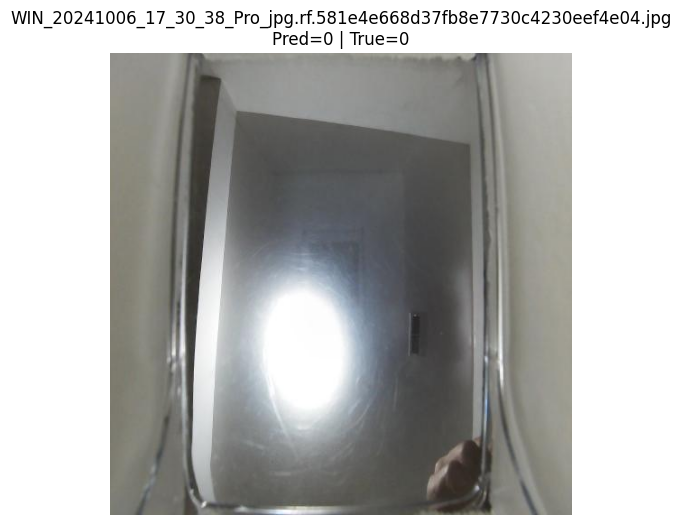

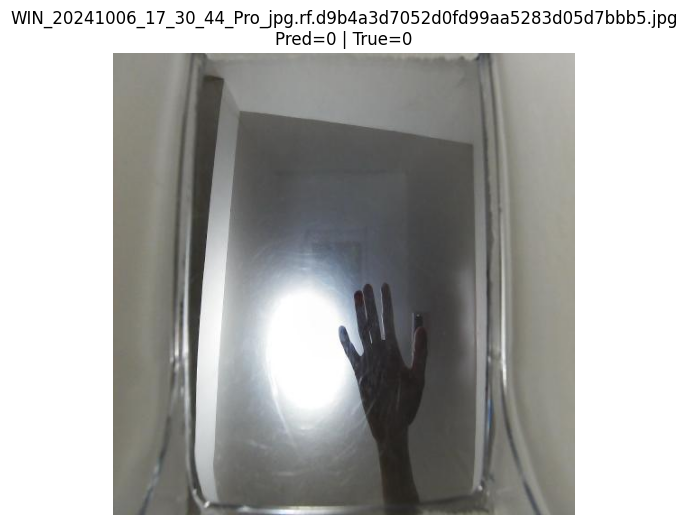

TRAIN COUNTING EVALUATION
Total evaluated images: 900
Mean Absolute Error (MAE): 0.2411
Root Mean Squared Error (RMSE): 0.6823
Exact Count Accuracy: 0.8344

Sample rows:
                                          image_name  true_count  pred_count  \
0  WIN_20241006_17_30_38_Pro_jpg.rf.581e4e668d37f...           0           0   
1  WIN_20241006_17_30_44_Pro_jpg.rf.d9b4a3d7052d0...           0           0   
2  WIN_20241006_17_30_48_Pro_jpg.rf.ba2c279c4f04a...           0           0   
3  WIN_20241006_17_31_26_Pro_jpg.rf.4d8107f75be42...           3           3   
4  WIN_20241006_17_31_31_Pro_jpg.rf.90405e3a065d3...           3           3   
5  WIN_20241006_17_32_20_Pro_jpg.rf.a7ca369c4f913...           3           3   
6  WIN_20241006_17_32_39_Pro_jpg.rf.3816c978c77ad...           3           3   
7  WIN_20241006_17_32_53_Pro_jpg.rf.e8b0d3977c84d...           3           3   
8  WIN_20241006_17_33_12_Pro_jpg.rf.8c7188ad52464...           4           4   
9  WIN_20241006_17_33_51_Pro_j

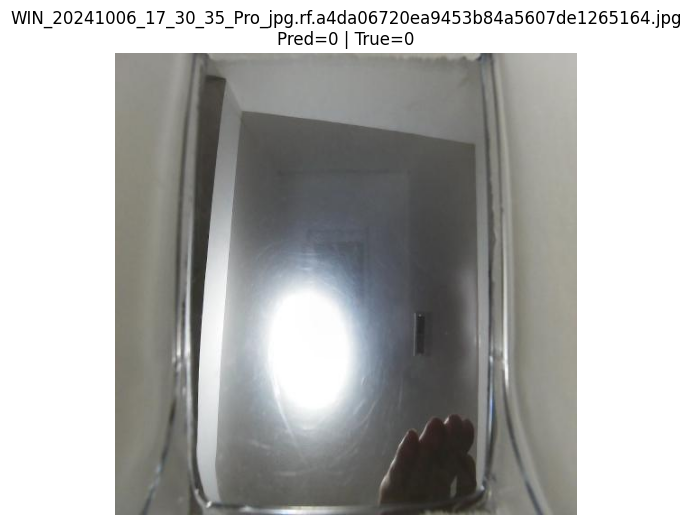

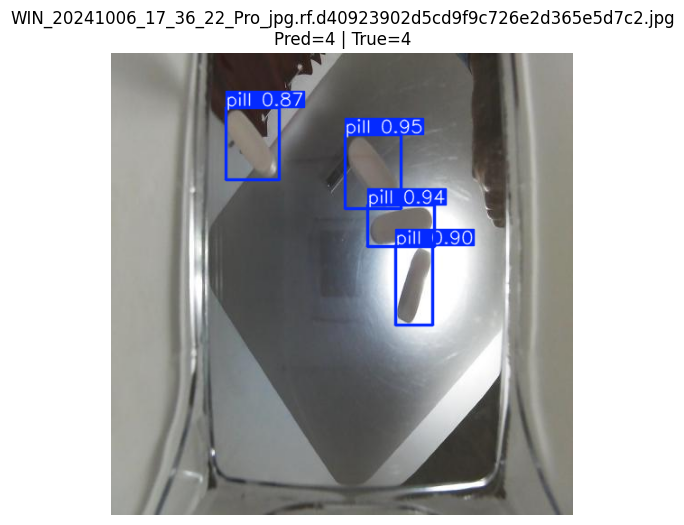

VAL COUNTING EVALUATION
Total evaluated images: 100
Mean Absolute Error (MAE): 0.3200
Root Mean Squared Error (RMSE): 0.8246
Exact Count Accuracy: 0.7600

Sample rows:
                                          image_name  true_count  pred_count  \
0  WIN_20241006_17_30_35_Pro_jpg.rf.a4da06720ea94...           0           0   
1  WIN_20241006_17_36_22_Pro_jpg.rf.d40923902d5cd...           4           4   
2  WIN_20241006_17_38_02_Pro_jpg.rf.ae19cde7a8ce0...           4           4   
3  WIN_20241006_17_41_28_Pro_jpg.rf.cd66a67d058d4...           3           3   
4  WIN_20241006_17_42_14_Pro_jpg.rf.12044011897d0...           0           0   
5  WIN_20241012_13_06_30_Pro_jpg.rf.7b198d2c23bd8...           4           4   
6  WIN_20241012_13_06_44_Pro_jpg.rf.e2c40c3dd267e...           2           2   
7  WIN_20241012_13_09_55_Pro_jpg.rf.82b4848f77bac...           0           0   
8  WIN_20241023_18_23_48_Pro_jpg.rf.8595fd1571765...           2           2   
9  WIN_20241023_18_40_54_Pro_jpg

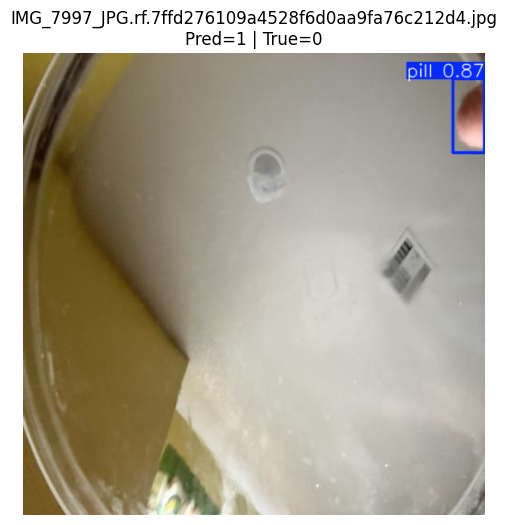

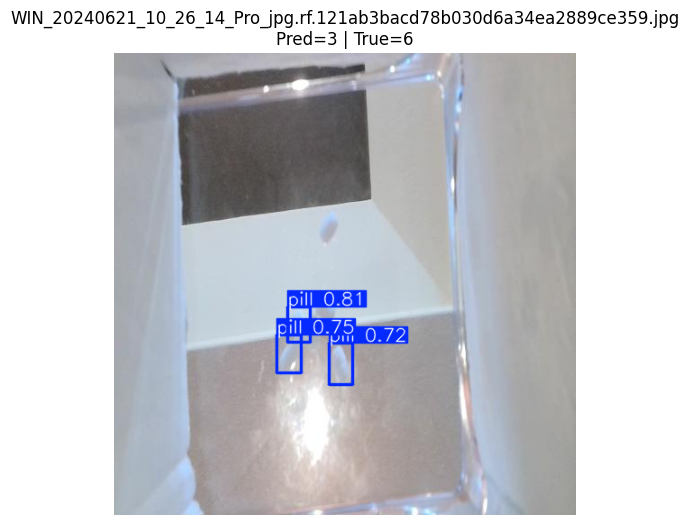

TEST COUNTING EVALUATION
Total evaluated images: 175
Mean Absolute Error (MAE): 0.3543
Root Mean Squared Error (RMSE): 0.8418
Exact Count Accuracy: 0.7657

Sample rows:
                                          image_name  true_count  pred_count  \
0  IMG_7997_JPG.rf.7ffd276109a4528f6d0aa9fa76c212...           0           1   
1  WIN_20240621_10_26_14_Pro_jpg.rf.121ab3bacd78b...           6           3   
2  WIN_20240621_10_27_58_Pro_jpg.rf.4f2649812aff3...           6           4   
3  WIN_20240621_10_30_33_Pro_jpg.rf.1398846787529...           3           3   
4  WIN_20240621_10_31_43_Pro_jpg.rf.517104f31cf5c...           0           0   
5  WIN_20240621_10_32_25_Pro_jpg.rf.d0f607df2f0ad...           2           1   
6  WIN_20240621_10_33_21_Pro_jpg.rf.1763b8bf166ef...           4           4   
7  WIN_20240621_10_34_16_Pro_jpg.rf.8487c8b589d05...           6           5   
8  WIN_20240621_10_36_54_Pro_jpg.rf.de14783c30d22...           2           2   
9  WIN_20240621_10_37_07_Pro_jp

In [47]:
DATASET_DIR = Path("/content/pill_dataset")
VAL_SPLIT_RATIO = 0.1 # ADDED: 10% of training data for validation

# Download only if not already present
if not DATASET_DIR.exists():
    print("Downloading dataset...")
    rf = Roboflow(api_key="wApF6XxjB6tJDmauw1s9")
    project = rf.workspace("reembashos-workspace").project("pill-detection-gvs4o")
    version = project.version(1)
    dataset = version.download(model_format="yolov8", location=str(DATASET_DIR))
else:
    print("Dataset directory already exists, skipping download.")

print("Dataset dir exists:", DATASET_DIR.exists())
print("Root contents:", os.listdir(DATASET_DIR))

# ============================================================
# 2.5) CREATE VALIDATION SPLIT IF NEEDED # ADDED: New section for validation split
# ============================================================
train_images_dir = DATASET_DIR / "train" / "images"
train_labels_dir = DATASET_DIR / "train" / "labels"
val_images_dir = DATASET_DIR / "val" / "images"
val_labels_dir = DATASET_DIR / "val" / "labels"

# Only create if val doesn't exist and train images are present
if not val_images_dir.exists() and train_images_dir.exists():
    print("\nCreating validation split from training data...")
    val_images_dir.mkdir(parents=True, exist_ok=True)
    val_labels_dir.mkdir(parents=True, exist_ok=True)

    all_train_image_files = list(train_images_dir.glob("*.*g")) # Consider common image extensions
    random.seed(42) # For reproducibility
    random.shuffle(all_train_image_files)

    num_val_images = int(len(all_train_image_files) * VAL_SPLIT_RATIO)
    val_image_files = all_train_image_files[:num_val_images]

    for img_path in val_image_files:
        # Move image
        shutil.move(str(img_path), str(val_images_dir / img_path.name))
        # Move corresponding label file
        label_path = train_labels_dir / f"{img_path.stem}.txt"
        if label_path.exists():
            shutil.move(str(label_path), str(val_labels_dir / label_path.name))
    print(f"Moved {num_val_images} images and labels to validation split.")
elif val_images_dir.exists():
    print("\nValidation split already exists. Skipping creation.")
else:
    print("\nTraining images directory not found or no images to split, cannot create validation split.")

# ============================================================
# 3) FIX data.yaml
# ============================================================
yaml_path = DATASET_DIR / "data.yaml"

with open(yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

data_cfg["path"] = str(DATASET_DIR)
data_cfg["train"] = "train/images"
data_cfg["test"] = "test/images"
# data_cfg["val"] = "test/images"   # REMOVED: Using dedicated validation split
data_cfg["val"] = "val/images"   # ADDED: Point to the new validation folder

with open(yaml_path, "w") as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)

print("\nFixed data.yaml:")
with open(yaml_path, "r") as f:
    print(f.read())

# ============================================================
# 4) FAST YOLO TRAINING ON GPU
# ============================================================
model = YOLO("yolo11n.pt")

train_results = model.train(
    data=str(yaml_path),
    epochs=5,                 # reduced
    imgsz=320,                 # smaller image
    batch=4,                   # lighter batch
    workers=2,                 # fewer workers for colab CPU
    patience=3,                # stop earlier
    project="/content/pill_yolo_runs",
    name="pill_count_detector_fast",
    pretrained=True,
    save=True,
    verbose=True
)

# ============================================================
# 5) LOAD BEST MODEL
# ============================================================
best_model_path = "/content/pill_yolo_runs/pill_count_detector_fast/weights/best.pt"
best_model = YOLO(best_model_path)

# ============================================================
# 6) HELPERS
# ============================================================
def get_true_count_from_label(label_path: Path) -> int:
    if not label_path.exists():
        return 0
    with open(label_path, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]
    return len(lines)

def evaluate_counting_with_yolo(model, split_dir, conf=0.7, iou=0.45, show_samples=3):
    split_dir = Path(split_dir)
    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"

    image_files = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]:
        image_files.extend(images_dir.glob(ext))
    image_files = sorted(image_files)

    rows = []
    shown = 0

    for img_path in image_files:
        results = model.predict(
            source=str(img_path),
            conf=conf,
            iou=iou,
            verbose=False
        )

        r = results[0]
        pred_count = 0 if r.boxes is None else len(r.boxes)

        label_path = labels_dir / f"{img_path.stem}.txt"
        true_count = get_true_count_from_label(label_path)

        rows.append({
            "image_name": img_path.name,
            "true_count": true_count,
            "pred_count": pred_count,
            "abs_error": abs(pred_count - true_count)
        })

        if shown < show_samples:
            annotated = r.plot()
            annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(6, 6))
            plt.imshow(annotated)
            plt.title(f"{img_path.name}\nPred={pred_count} | True={true_count}")
            plt.axis("off")
            plt.show()
            shown += 1

    df = pd.DataFrame(rows)

    mae = float(df["abs_error"].mean())
    rmse = float(np.sqrt(np.mean((df["pred_count"] - df["true_count"]) ** 2)))
    exact_acc = float((df["pred_count"] == df["true_count"]).mean())

    print("=" * 60)
    print(f"{split_dir.name.upper()} COUNTING EVALUATION")
    print("=" * 60)
    print(f"Total evaluated images: {len(df)}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Exact Count Accuracy: {exact_acc:.4f}")
    print("\nSample rows:")
    print(df.head(10))

    return df, {"mae": mae, "rmse": rmse, "exact_acc": exact_acc}

# ============================================================
# 7) RUN EVALUATION
# ============================================================
train_df, train_stats = evaluate_counting_with_yolo(
    best_model,
    DATASET_DIR / "train",
    conf=0.7, # UPDATED
    iou=0.45,
    show_samples=2
)

val_df, val_stats = evaluate_counting_with_yolo(
    best_model,
    DATASET_DIR / "val",
    conf=0.7, # UPDATED
    iou=0.45,
    show_samples=2
)

test_df, test_stats = evaluate_counting_with_yolo(
    best_model,
    DATASET_DIR / "test",
    conf=0.7, # UPDATED
    iou=0.45,
    show_samples=2
)

# ============================================================
# 8) SAVE RESULTS
# ============================================================
train_df.to_csv("/content/yolo_train_count_results_fast.csv", index=False)
val_df.to_csv("/content/yolo_val_count_results_fast.csv", index=False)
test_df.to_csv("/content/yolo_test_count_results_fast.csv", index=False)

print("\nSaved fast results.")

### Helper to evaluate a single image

In [21]:
def evaluate_single_image(model, image_name: str, split_dir: Path, conf=0.7, iou=0.45):
    split_dir = Path(split_dir)
    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"

    img_path = images_dir / image_name

    if not img_path.exists():
        print(f"Error: Image not found at {img_path}")
        return

    results = model.predict(
        source=str(img_path),
        conf=conf,
        iou=iou,
        verbose=False
    )

    r = results[0]
    pred_count = 0 if r.boxes is None else len(r.boxes)

    label_path = labels_dir / f"{img_path.stem}.txt"
    true_count = get_true_count_from_label(label_path)

    print(f"\nEvaluating: {image_name}")
    print(f"Predicted Count: {pred_count}")
    print(f"True Count: {true_count}")
    print(f"Absolute Error: {abs(pred_count - true_count)}")

    annotated = r.plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(annotated)
    plt.title(f"Image: {image_name}\nPred={pred_count} | True={true_count}")
    plt.axis("off")
    plt.show()

### Helper to predict and display for any image (without true count)

In [22]:
def predict_and_display_image(model, image_path: Path, conf=0.7, iou=0.45):
    if not image_path.exists():
        print(f"Error: Image not found at {image_path}")
        return

    results = model.predict(
        source=str(image_path),
        conf=conf,
        iou=iou,
        verbose=False
    )

    r = results[0]
    pred_count = 0 if r.boxes is None else len(r.boxes)

    print(f"\nEvaluating: {image_path.name}")
    print(f"Predicted Count: {pred_count}")

    annotated = r.plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(annotated)
    plt.title(f"Image: {image_path.name}\nPredicted Count={pred_count}")
    plt.axis("off")
    plt.show()

### Final Prediction Function for Project Use

In [48]:
def predict_count_and_decision(
    model: YOLO,
    image_path: Path,
    expected_count: int = None,
    conf: float = 0.7,
    iou: float = 0.45,
    show: bool = True
) -> dict:
    """
    Performs pill counting inference on a single image, validates the input,
    makes a dosage decision, and returns project-use outputs that are easy to
    adapt into the UI.

    Args:
        model (YOLO): The trained YOLO model.
        image_path (Path): Path to the image file.
        expected_count (int, optional): The expected number of pills for dosage decision.
                                        Defaults to None.
        conf (float): Confidence threshold for detections.
        iou (float): IoU threshold for Non-Maximum Suppression.
        show (bool): Whether to display the annotated image.

    Returns:
        dict: A dictionary containing:
            - 'image_name': Name of the image file.
            - 'image_path': Full path to the image file.
            - 'validation_status': 'valid', 'warning', or 'error' from validation.
            - 'validation_message': Message from image validation.
            - 'predicted_count': Number of pills detected.
            - 'expected_count': The provided expected count.
            - 'decision': 'correct', 'too few', 'too many', or None if no expected_count.
            - 'ui_status': 'Correct dosage', 'Too few', 'Too many', or None.
            - 'confidences': List of confidence scores for each detected box.
            - 'avg_confidence': Average confidence across detected boxes.
            - 'boxes_xyxy': List of bounding box coordinates (x1, y1, x2, y2) for each detected box.
            - 'annotated_image': RGB annotated image array for display/reuse.
            - 'image_width': Width of the processed image.
            - 'image_height': Height of the processed image.
            - 'raw_results': The raw YOLO results object (for advanced use).
    """

    ui_status_map = {
        'correct': 'Correct dosage',
        'too few': 'Too few',
        'too many': 'Too many'
    }

    results_dict = {
        'image_name': image_path.name,
        'image_path': str(image_path),
        'validation_status': 'error',
        'validation_message': 'Initialization error',
        'predicted_count': 0,
        'expected_count': expected_count,
        'decision': None,
        'ui_status': None,
        'confidences': [],
        'avg_confidence': 0.0,
        'boxes_xyxy': [],
        'annotated_image': None,
        'image_width': 0,
        'image_height': 0,
        'raw_results': None
    }

    # 1. Validate image input
    validation_result = validate_image_for_inference(image_path)
    results_dict['validation_status'] = validation_result['status']
    results_dict['validation_message'] = validation_result['message']

    if validation_result['status'] == 'error':
        print(f"Error processing {image_path.name}: {validation_result['message']}")
        return results_dict

    # Use the image loaded by validation to get dimensions
    validated_img = validation_result['image']
    results_dict['image_height'], results_dict['image_width'] = validated_img.shape[:2]

    # 2. Perform YOLO inference
    try:
        yolo_results = model.predict(
            source=str(image_path),
            conf=conf,
            iou=iou,
            verbose=False
        )

        r = yolo_results[0]
        results_dict['raw_results'] = r

        if r.boxes is not None:
            results_dict['predicted_count'] = len(r.boxes)
            results_dict['confidences'] = r.boxes.conf.tolist()
            results_dict['boxes_xyxy'] = r.boxes.xyxy.tolist()
            if results_dict['confidences']:
                results_dict['avg_confidence'] = float(np.mean(results_dict['confidences']))
        else:
            results_dict['predicted_count'] = 0

        annotated_img = r.plot()
        annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
        results_dict['annotated_image'] = annotated_img

    except Exception as e:
        results_dict['validation_status'] = 'error'
        results_dict['validation_message'] = f"Inference error: {e}"
        print(f"Inference error on {image_path.name}: {e}")
        return results_dict

    # 3. Determine dosage decision
    if expected_count is not None:
        results_dict['decision'] = dosage_decision(results_dict['predicted_count'], expected_count)
        results_dict['ui_status'] = ui_status_map.get(results_dict['decision'])

    # 4. Display annotated image if requested
    if show and results_dict['annotated_image'] is not None:
        title_str = f"Image: {image_path.name}\nPred={results_dict['predicted_count']}"
        if expected_count is not None:
            title_str += f" | Expected={expected_count} | Decision: {results_dict['decision']}"
        if results_dict['validation_status'] == 'warning':
            title_str += f"\n(Warning: {results_dict['validation_message']})"

        plt.figure(figsize=(8, 8))
        plt.imshow(results_dict['annotated_image'])
        plt.title(title_str)
        plt.axis("off")
        plt.show()

    # Set validation_status to valid if no prior errors/warnings
    if results_dict['validation_status'] not in ['error', 'warning']:
        results_dict['validation_status'] = 'valid'
        results_dict['validation_message'] = 'Image processed successfully.'

    return results_dict

### 5) Counting-focused Threshold Analysis

This section evaluates the model's counting performance (MAE, RMSE, Exact Accuracy) across different confidence and IoU thresholds on the validation set. The goal is to identify a threshold pair that optimizes counting metrics, rather than object detection metrics like mAP.

In [49]:
threshold_results = []

# Define a range of confidence and IoU thresholds to test
conf_thresholds = [0.1, 0.25, 0.4, 0.5, 0.7] # UPDATED
iou_thresholds = [0.2, 0.45, 0.6]

print("Starting threshold analysis on validation set...")

for conf_t in conf_thresholds:
    for iou_t in iou_thresholds:
        print(f"\nEvaluating with conf={conf_t:.2f}, iou={iou_t:.2f}...")
        # Use show_samples=0 to avoid plotting too many images during this analysis
        val_df_current, val_stats_current = evaluate_counting_with_yolo(
            best_model,
            DATASET_DIR / "val",
            conf=conf_t,
            iou=iou_t,
            show_samples=0 # Do not show samples during threshold search
        )
        threshold_results.append({
            "conf": conf_t,
            "iou": iou_t,
            "mae": val_stats_current["mae"],
            "rmse": val_stats_current["rmse"],
            "exact_acc": val_stats_current["exact_acc"]
        })

threshold_df = pd.DataFrame(threshold_results)
print("\nThreshold Analysis Results (Validation Set):")
print(threshold_df.round(4))

# Optionally, find the best threshold based on a metric, e.g., lowest MAE
best_mae_row = threshold_df.loc[threshold_df['mae'].idxmin()]
print(f"\nBest MAE on validation set: conf={best_mae_row['conf']:.2f}, iou={best_mae_row['iou']:.2f} (MAE: {best_mae_row['mae']:.4f})")

# Update best_conf and best_iou if needed for subsequent cells
best_conf_for_counting = best_mae_row['conf']
best_iou_for_counting = best_mae_row['iou']

print(f"\nSelected best counting thresholds: conf={best_conf_for_counting:.2f}, iou={best_iou_for_counting:.2f}")

Starting threshold analysis on validation set...

Evaluating with conf=0.10, iou=0.20...
VAL COUNTING EVALUATION
Total evaluated images: 100
Mean Absolute Error (MAE): 0.4500
Root Mean Squared Error (RMSE): 0.9110
Exact Count Accuracy: 0.6900

Sample rows:
                                          image_name  true_count  pred_count  \
0  WIN_20241006_17_30_35_Pro_jpg.rf.a4da06720ea94...           0           0   
1  WIN_20241006_17_36_22_Pro_jpg.rf.d40923902d5cd...           4           4   
2  WIN_20241006_17_38_02_Pro_jpg.rf.ae19cde7a8ce0...           4           4   
3  WIN_20241006_17_41_28_Pro_jpg.rf.cd66a67d058d4...           3           3   
4  WIN_20241006_17_42_14_Pro_jpg.rf.12044011897d0...           0           0   
5  WIN_20241012_13_06_30_Pro_jpg.rf.7b198d2c23bd8...           4           5   
6  WIN_20241012_13_06_44_Pro_jpg.rf.e2c40c3dd267e...           2           3   
7  WIN_20241012_13_09_55_Pro_jpg.rf.82b4848f77bac...           0           0   
8  WIN_20241023_18_23_4

### 6) Better Error Analysis

This section provides more detailed insights into the model's counting errors by analyzing undercounts, exact matches, and overcounts, visualizing the distribution of absolute errors, and highlighting images with the largest discrepancies. We will use the `val_df` from the previous evaluation with the default thresholds for this analysis, but you can re-run with `best_conf_for_counting` and `best_iou_for_counting` if you wish to analyze the best thresholds found.

In [50]:
def dosage_decision(pred_count, expected_count):
    if pred_count == expected_count:
        return "correct"
    elif pred_count < expected_count:
        return "too few"
    else:
        return "too many"


--- Detailed Error Analysis on Validation Set (Default Thresholds) ---

Error Type Frequencies:
error_type
exact         76.0
undercount    21.0
overcount      3.0

Absolute Error Distribution:
abs_error
0    76
1    20
2     3
6     1


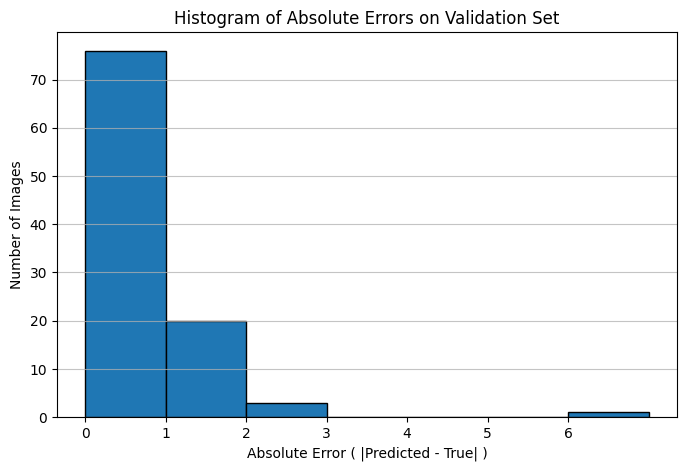


--- Worst Error Images (Validation Set) ---


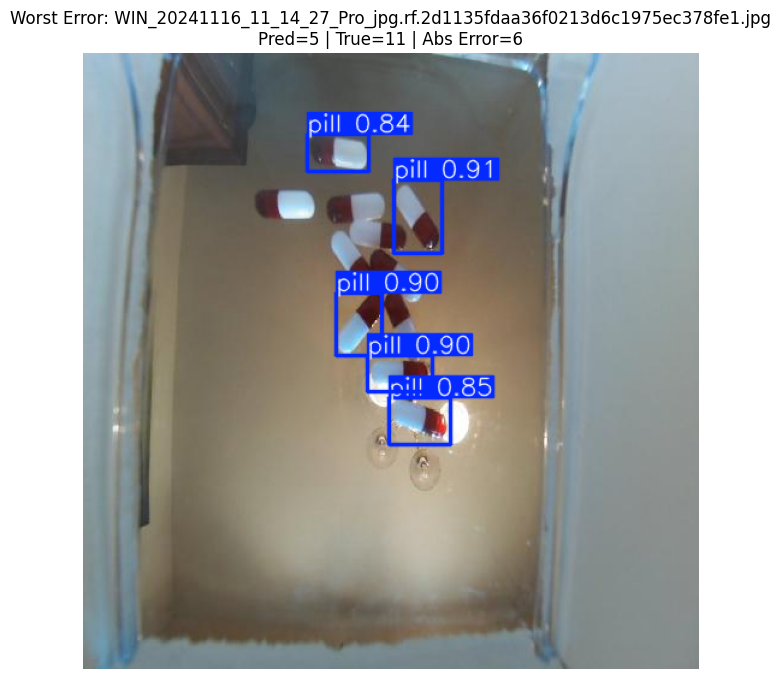

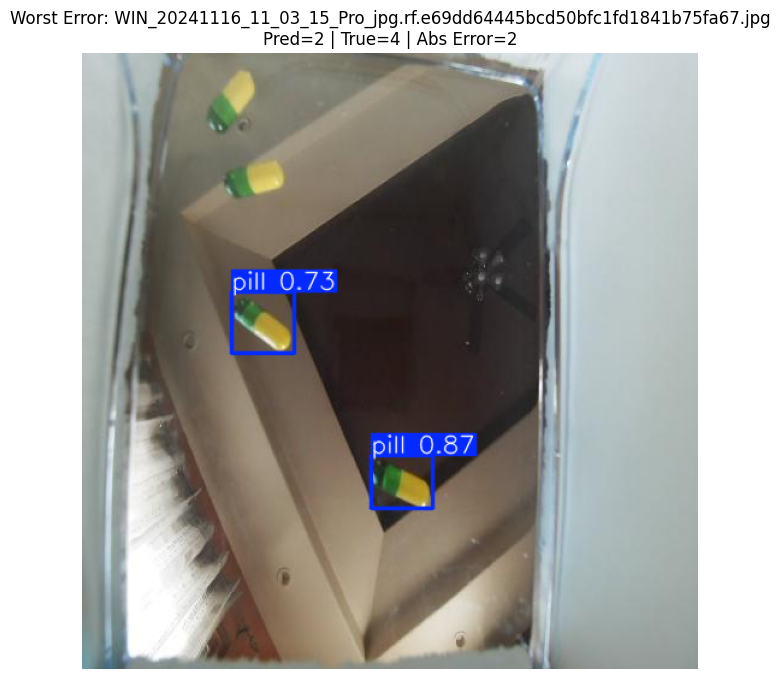

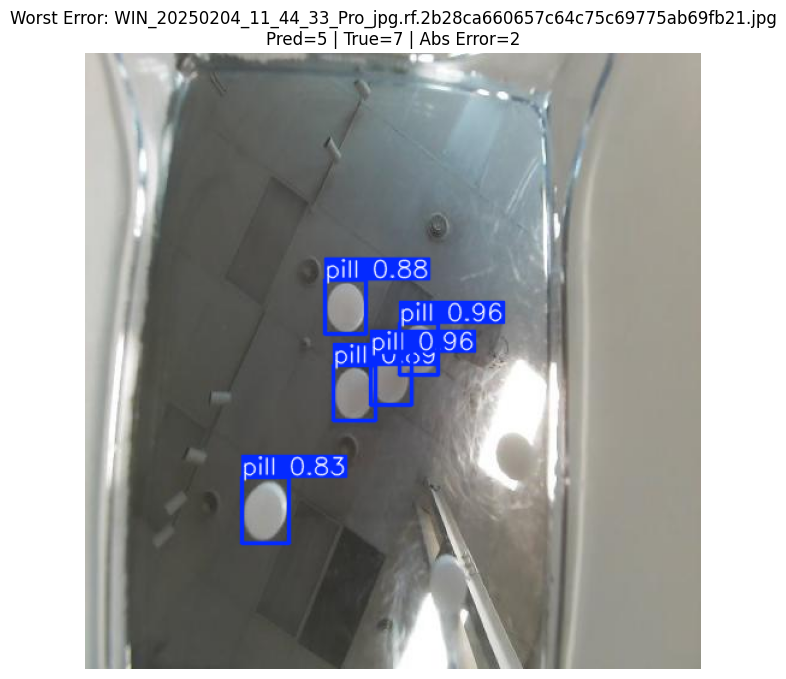

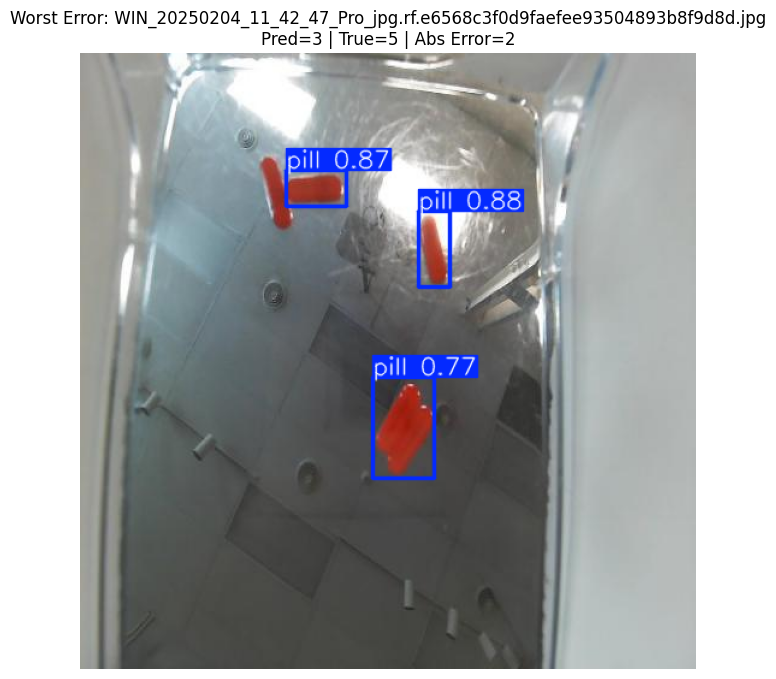

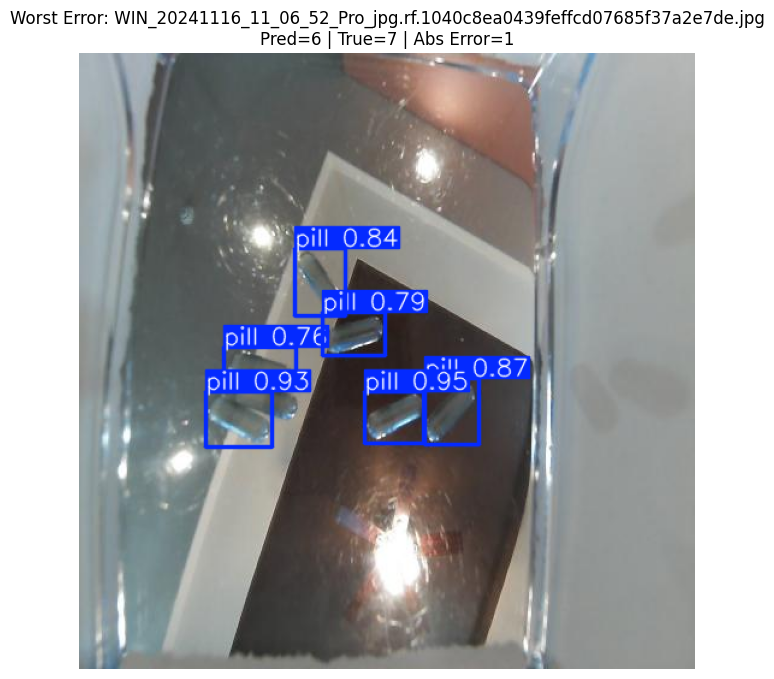


--- Sample Per-Image Decision Results (Validation Set) ---
                                                              image_name  true_count  pred_count  abs_error error_type decision
0  WIN_20241006_17_30_35_Pro_jpg.rf.a4da06720ea9453b84a5607de1265164.jpg           0           0          0      exact  correct
1  WIN_20241006_17_36_22_Pro_jpg.rf.d40923902d5cd9f9c726e2d365e5d7c2.jpg           4           4          0      exact  correct
2  WIN_20241006_17_38_02_Pro_jpg.rf.ae19cde7a8ce01bf601d363abee7fec0.jpg           4           4          0      exact  correct
3  WIN_20241006_17_41_28_Pro_jpg.rf.cd66a67d058d4debde0c25e00d4b06ee.jpg           3           3          0      exact  correct
4  WIN_20241006_17_42_14_Pro_jpg.rf.12044011897d0e92813f0e3083b60cb8.jpg           0           0          0      exact  correct
5  WIN_20241012_13_06_30_Pro_jpg.rf.7b198d2c23bd84fde4699e12c0617999.jpg           4           4          0      exact  correct
6  WIN_20241012_13_06_44_Pro_jpg.rf.e2c40c3d

In [51]:
# Using val_df obtained with default thresholds from previous evaluation for this analysis
# If you want to use the best thresholds found, re-run evaluate_counting_with_yolo here with best_conf_for_counting and best_iou_for_counting

print("\n--- Detailed Error Analysis on Validation Set (Default Thresholds) ---")

# 1. Undercount / Exact / Overcount Frequencies
val_df['error_type'] = 'exact'
val_df.loc[val_df['pred_count'] < val_df['true_count'], 'error_type'] = 'undercount'
val_df.loc[val_df['pred_count'] > val_df['true_count'], 'error_type'] = 'overcount'

error_type_counts = val_df['error_type'].value_counts(normalize=True) * 100
print("\nError Type Frequencies:")
print(error_type_counts.round(2).to_string())

# 2. Histogram or table of abs_error
print("\nAbsolute Error Distribution:")
print(val_df['abs_error'].value_counts().sort_index().to_string())

plt.figure(figsize=(8, 5))
val_df['abs_error'].plot(kind='hist', bins=range(int(val_df['abs_error'].max()) + 2), edgecolor='black')
plt.title('Histogram of Absolute Errors on Validation Set')
plt.xlabel('Absolute Error ( |Predicted - True| )')
plt.ylabel('Number of Images')
plt.xticks(range(int(val_df['abs_error'].max()) + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

# 3. Show worst-error images
print("\n--- Worst Error Images (Validation Set) ---")
worst_errors = val_df.sort_values(by='abs_error', ascending=False).head(5)

for index, row in worst_errors.iterrows():
    image_name = row['image_name']
    true_count = row['true_count']
    pred_count = row['pred_count']
    abs_error = row['abs_error']

    img_path = DATASET_DIR / "val" / "images" / image_name
    if not img_path.exists():
        print(f"Warning: Image {image_name} not found at {img_path}, skipping display.")
        continue

    results = best_model.predict(
        source=str(img_path),
        conf=0.7, # UPDATED
        iou=0.45,
        verbose=False
    )

    r = results[0]
    annotated = r.plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(annotated)
    plt.title(f"Worst Error: {image_name}\nPred={pred_count} | True={true_count} | Abs Error={abs_error}")
    plt.axis("off")
    plt.show()

# 4. Show per-image decision result (if expected_count is available - using true_count for this demo)
print("\n--- Sample Per-Image Decision Results (Validation Set) ---")
# For error analysis, we can simulate expected_count == true_count
val_df['decision'] = val_df.apply(lambda row: dosage_decision(row['pred_count'], row['true_count']), axis=1)
print(val_df[['image_name', 'true_count', 'pred_count', 'abs_error', 'error_type', 'decision']].head(10).to_string())

### 7) Decision Evaluation

This section evaluates the accuracy of the `dosage_decision` function. We compare the model's `predicted_count` against a given `expected_count` and report how often the decision (correct, too few, too many) is accurate. For technical evaluation, `expected_count` can be set to `true_count` from labels. For demo purposes, we can simulate other `expected_count` values.

In [52]:
def evaluate_decision_accuracy(df: pd.DataFrame, expected_col: str) -> dict:
    """
    Evaluates the accuracy of the dosage decision based on a given expected count column.

    Args:
        df (pd.DataFrame): DataFrame with 'predicted_count' and 'true_count'/'expected_count' columns.
        expected_col (str): The name of the column to use as the 'expected_count' (e.g., 'true_count').

    Returns:
        dict: Dictionary containing decision accuracy metrics.
    """
    temp_df = df.copy()
    temp_df['decision'] = temp_df.apply(lambda row: dosage_decision(row['pred_count'], row[expected_col]), axis=1)
    temp_df['true_decision'] = temp_df.apply(lambda row: dosage_decision(row['true_count'], row[expected_col]), axis=1)
    temp_df['decision_correct'] = (temp_df['decision'] == temp_df['true_decision'])

    accuracy = temp_df['decision_correct'].mean()
    print(f"Total Images: {len(temp_df)}")
    print(f"Decision Accuracy (comparing predicted decision to true decision): {accuracy:.4f}")

    # More detailed breakdown
    print("\nDecision Breakdown (Predicted vs. True):")
    print(pd.crosstab(temp_df['true_decision'], temp_df['decision']))

    return {"decision_accuracy": accuracy}

print("\n--- Decision Evaluation ---")
print("Evaluating decision accuracy using 'true_count' as 'expected_count':")
decision_stats_true_count = evaluate_decision_accuracy(val_df, 'true_count')

# Example of simulating an expected count (e.g., always expecting 3 pills)
print("\nEvaluating decision accuracy with a simulated 'expected_count' (always 3):")
simulated_df = val_df.copy()
simulated_df['simulated_expected'] = 3
decision_stats_simulated = evaluate_decision_accuracy(simulated_df, 'simulated_expected')



--- Decision Evaluation ---
Evaluating decision accuracy using 'true_count' as 'expected_count':
Total Images: 100
Decision Accuracy (comparing predicted decision to true decision): 0.7600

Decision Breakdown (Predicted vs. True):
decision       correct  too few  too many
true_decision                            
correct             76       21         3

Evaluating decision accuracy with a simulated 'expected_count' (always 3):
Total Images: 100
Decision Accuracy (comparing predicted decision to true decision): 0.8600

Decision Breakdown (Predicted vs. True):
decision       correct  too few  too many
true_decision                            
correct             16        7         0
too few              1       37         0
too many             5        1        33


### 8) Reproducibility Summary Cell

This final cell provides a concise summary of the key parameters, dataset statistics, model details, and evaluation metrics for reproducibility and quick overview.

In [53]:
print("""
=========================================================
              PILL COUNTING PROJECT SUMMARY
=========================================================
""")

print("**1. Dataset Information:**")
print(f"  Dataset Path: {DATASET_DIR}")
print(f"  Train Images: {len(os.listdir(DATASET_DIR / 'train' / 'images'))}")
print(f"  Val Images: {len(os.listdir(DATASET_DIR / 'val' / 'images'))}")
print(f"  Test Images: {len(os.listdir(DATASET_DIR / 'test' / 'images'))}")
print(f"  Validation Split Ratio: {VAL_SPLIT_RATIO:.2f}")

print("\n**2. Model Training Details:**")
# Load training arguments from args.yaml as train_results.args is not available on DetMetrics object
import yaml
train_args_path = Path(train_results.save_dir) / 'args.yaml'
if train_args_path.exists():
    with open(train_args_path, 'r') as f:
        training_args = yaml.safe_load(f)
    print(f"  Model Used: {training_args.get('model', 'N/A')}")
    print(f"  Training Epochs: {training_args.get('epochs', 'N/A')}")
    print(f"  Image Size (imgsz): {training_args.get('imgsz', 'N/A')}")
    print(f"  Batch Size: {training_args.get('batch', 'N/A')}")
    print(f"  Patience: {training_args.get('patience', 'N/A')}")
    print(f"  Run Directory: {train_results.save_dir}")
else:
    print("  Training arguments (args.yaml) not found.")
    print(f"  Run Directory: {train_results.save_dir}")

print("\n**3. Evaluation Thresholds (for counting):**")
# Assuming best_conf_for_counting and best_iou_for_counting are set by threshold analysis
if 'best_conf_for_counting' in locals() and 'best_iou_for_counting' in locals():
    print(f"  Selected Confidence Threshold: {best_conf_for_counting:.2f}")
    print(f"  Selected IoU Threshold: {best_iou_for_counting:.2f}")
else:
    print(f"  Default Evaluation Confidence Threshold: {conf_thresholds[1]:.2f}") # Using 0.25 as default
    print(f"  Default Evaluation IoU Threshold: {iou_thresholds[1]:.2f}") # Using 0.45 as default

print("\n**4. Counting Metrics (Default Thresholds):**")
print("  --- Training Set ---")
print(f"    MAE: {train_stats['mae']:.4f}")
print(f"    RMSE: {train_stats['rmse']:.4f}")
print(f"    Exact Accuracy: {train_stats['exact_acc']:.4f}")
print("  --- Validation Set ---")
print(f"    MAE: {val_stats['mae']:.4f}")
print(f"    RMSE: {val_stats['rmse']:.4f}")
print(f"    Exact Accuracy: {val_stats['exact_acc']:.4f}")
print("  --- Test Set ---")
print(f"    MAE: {test_stats['mae']:.4f}")
print(f"    RMSE: {test_stats['rmse']:.4f}")
print(f"    Exact Accuracy: {test_stats['exact_acc']:.4f}")

print("\n**5. Decision Evaluation (using true_count as expected_count):**")
if 'decision_stats_true_count' in locals():
    print(f"  Decision Accuracy: {decision_stats_true_count['decision_accuracy']:.4f}")
else:
    print("  Decision evaluation not run or results not available.")

print("""
=========================================================
""")


              PILL COUNTING PROJECT SUMMARY

**1. Dataset Information:**
  Dataset Path: /content/pill_dataset
  Train Images: 900
  Val Images: 100
  Test Images: 175
  Validation Split Ratio: 0.10

**2. Model Training Details:**
  Model Used: yolo11n.pt
  Training Epochs: 5
  Image Size (imgsz): 320
  Batch Size: 4
  Patience: 3
  Run Directory: /content/pill_yolo_runs/pill_count_detector_fast4

**3. Evaluation Thresholds (for counting):**
  Selected Confidence Threshold: 0.50
  Selected IoU Threshold: 0.45

**4. Counting Metrics (Default Thresholds):**
  --- Training Set ---
    MAE: 0.2411
    RMSE: 0.6823
    Exact Accuracy: 0.8344
  --- Validation Set ---
    MAE: 0.3200
    RMSE: 0.8246
    Exact Accuracy: 0.7600
  --- Test Set ---
    MAE: 0.3543
    RMSE: 0.8418
    Exact Accuracy: 0.7657

**5. Decision Evaluation (using true_count as expected_count):**
  Decision Accuracy: 0.7600




### Evaluate the requested image


Evaluating: WIN_20241116_11_12_50_Pro_jpg.rf.c8ffd57b5337dffe00086f9c2a2d1d63.jpg
Predicted Count: 3
True Count: 3
Absolute Error: 0


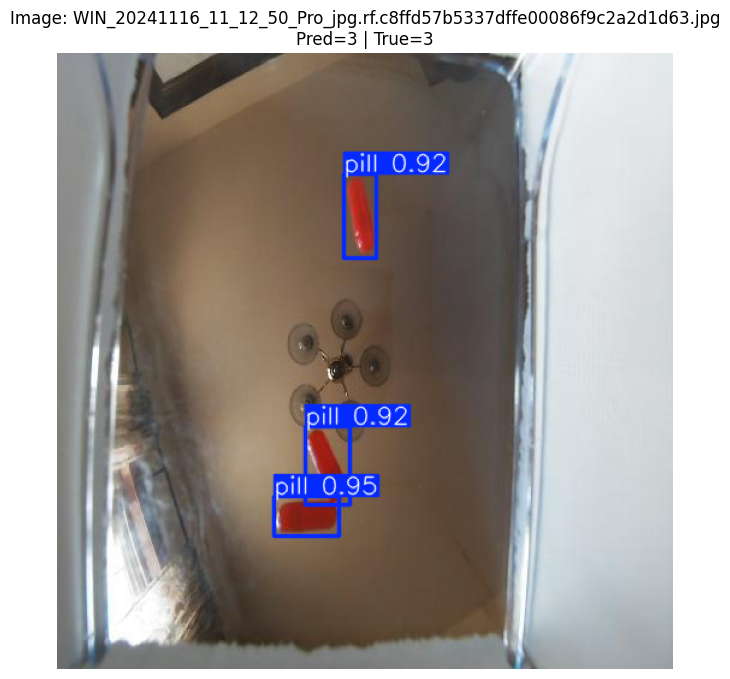

In [54]:
evaluate_single_image(
    best_model,
    image_name="WIN_20241116_11_12_50_Pro_jpg.rf.c8ffd57b5337dffe00086f9c2a2d1d63.jpg",
    split_dir=DATASET_DIR / "test",
    conf=0.7, # UPDATED
    iou=0.45
)

### Evaluate an image from the dataset

Found first valid image in test set: WIN_20241004_18_25_31_Pro_jpg.rf.36e272549ddedbba7b897f57568d29d9.jpg

Evaluating: WIN_20241004_18_25_31_Pro_jpg.rf.36e272549ddedbba7b897f57568d29d9.jpg
Predicted Count: 3
True Count: 3
Absolute Error: 0


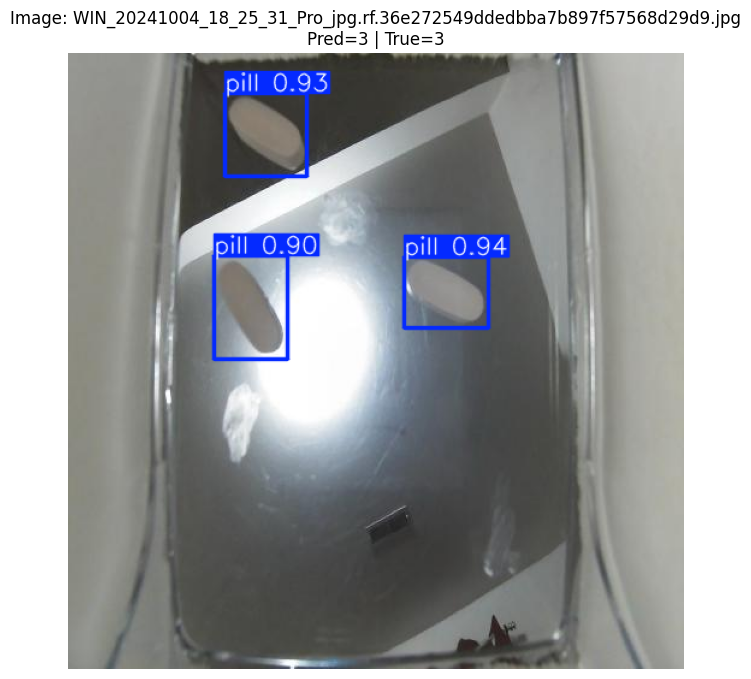

In [55]:
import os

# Get a list of all files in the test/images directory
test_images_dir = DATASET_DIR / "test" / "images"
files_in_dir = [f for f in os.listdir(test_images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

if files_in_dir:
    first_valid_image = files_in_dir[0]
    print(f"Found first valid image in test set: {first_valid_image}")
    evaluate_single_image(
        best_model,
        image_name=first_valid_image,
        split_dir=DATASET_DIR / "test",
        conf=0.7, # UPDATED
        iou=0.45
    )
else:
    print(f"No image files found in {test_images_dir}. Please check the dataset contents.")

current pipeline count quality depends heavily on:

confidence threshold

IoU threshold

duplicate detections

false positives on background/noise

=> to add:
evaluate a few threshold settings; choose the threshold pair with lowest MAE on validation/test

rule-based dosage decision:

correct,
too few,
too many

In [56]:
def dosage_decision(pred_count, expected_count):
    if pred_count == expected_count:
        return "correct"
    elif pred_count < expected_count:
        return "too few"
    else:
        return "too many"

when user enters an image, validate it

check file exists

verify readable image

reject empty/corrupt image

warn on very small image

warn on blurry/low-contrast image rather than failing

In [57]:
import cv2
import numpy as np
from pathlib import Path

def validate_image_for_inference(image_path: Path, min_dim: int = 64, blur_threshold: float = 100.0, contrast_threshold: float = 5.0) -> dict:
    """
    Validates an image file for inference.

    Args:
        image_path (Path): Path to the image file.
        min_dim (int): Minimum acceptable dimension (width or height) for an image.
        blur_threshold (float): Threshold for Laplacian variance; lower means more blurry.
        contrast_threshold (float): Threshold for standard deviation of pixel intensities; lower means lower contrast.

    Returns:
        dict: A dictionary containing:
            - 'status': 'valid', 'warning', or 'error'
            - 'message': Description of the validation result.
            - 'image': The loaded OpenCV image (if valid/warning), else None.
    """
    validation_status = {"status": "error", "message": "", "image": None}
    messages = []

    # 1. Check file existence
    if not image_path.exists():
        validation_status["message"] = f"Error: Image file not found at {image_path}"
        return validation_status
    if not image_path.is_file():
        validation_status["message"] = f"Error: Path is not a file: {image_path}"
        return validation_status

    # 2. Check OpenCV can read it
    img = cv2.imread(str(image_path))
    if img is None:
        validation_status["message"] = f"Error: OpenCV could not read image file {image_path}. It might be corrupt or an unsupported format."
        return validation_status

    # 3. Check image is not empty
    if img.size == 0:
        validation_status["message"] = f"Error: Image file {image_path} is empty."
        return validation_status

    # 4. Warn on very small image
    height, width = img.shape[:2]
    if width < min_dim or height < min_dim:
        messages.append(f"Warning: Image dimensions ({width}x{height}) are very small. This might affect detection quality.")
        validation_status["status"] = "warning" # Promote status to warning if not error

    # 5. Optionally warn on blurry/low-contrast image
    # Convert to grayscale for blur and contrast detection
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img

    # Blur detection using Laplacian variance
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    if laplacian_var < blur_threshold:
        messages.append(f"Warning: Image might be blurry (Laplacian variance: {laplacian_var:.2f} < {blur_threshold:.2f}).")
        validation_status["status"] = "warning"

    # Contrast detection using standard deviation of pixel intensities
    contrast = np.std(gray)
    if contrast < contrast_threshold:
        messages.append(f"Warning: Image might have low contrast (Std Dev: {contrast:.2f} < {contrast_threshold:.2f}).")
        validation_status["status"] = "warning"

    if not messages:
        validation_status["status"] = "valid"
        validation_status["message"] = f"Image {image_path.name} is valid."
    else:
        if validation_status["status"] != "error": # Ensure error state is not overwritten by a warning
            validation_status["status"] = "warning"
        validation_status["message"] = f"Image {image_path.name}: " + " ".join(messages)

    validation_status["image"] = img
    return validation_status